# 03. MLP con PINN como función de Pérdida utilizando Optuna

## 1. Introducción

## 2. Implementación

Primeramente se importan los módulos necesarios para la realización de esta
etapa.

In [1]:
# Se recarga el paquete src
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import torch.optim as optim
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import optuna

# Se importan los módulos internos del paquete src
from src.dataset.dataset import RadiationDataset
from src.learning.models import PINNEmbrittlement, pinn_loss

/home/lonelywolf/miniforge3/envs/tfm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Después se carga el Dataset y se preprocesa.

In [ ]:
# 1. Instanciar el Dataset personalizado
csv_path = '../data/df_plotter_cm2.csv'
dataset = RadiationDataset(csv_path)

# 2. División inicial (Dejamos el 80% para entrenar/buscar y un 20% AISLADO para testear al final)
# OJO: Dependiendo de cómo esté tu método data_split, devuelve (train, val, test) o similar.
# Asumimos la estructura del código anterior donde el segundo valor devuelto no lo usábamos.
train_val_set, _, test_set = dataset.data_split(test_factor=0.2)

# 3. Preprocesamiento: El escalador se entrena con TODO       el bloque de entrenamiento
dataset.preprocess(train_val_set, preprocessor=StandardScaler())

# 4. DataLoaders
# El DataLoader completo de entrenamiento lo usaremos luego para el modelo final
full_train_loader = DataLoader(train_val_set, batch_size=32, shuffle=True)

# El DataLoader de test se queda esperando para la evaluación final
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Datos preparados. Full Train (para K-Fold y Final): {len(train_val_set)} | Test: {len(test_set)}")

Datos preparados. Full Train (para K-Fold y Final): 1511 | Test: 378


Se crea objeto de la red neuronal y se buscan mejores hiperparámetros con
optuna.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilizando dispositivo: {device}")

# Configuración del K-Fold (3 pliegues es un buen balance tiempo/precisión)
K_FOLDS = 3
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

def objective(trial):
    # Sugerencias de parámetros conservadores para datos tabulares
    num_layers = trial.suggest_int("num_layers", 2, 4)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    activation_name = trial.suggest_categorical("activation", ["SiLU", "GELU"])
    lr = trial.suggest_float("learning_rate", 5e-4, 5e-3, log=True)
    lambda_mono = trial.suggest_float("lambda_mono", 0.1, 1.0)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    
    activations = {"SiLU": nn.SiLU, "GELU": nn.GELU, "Tanh": nn.Tanh}
    epochs_search = 100 # Algo más bajo porque multiplicamos x3 por los folds
    
    fold_losses = []
    dataset_indices = list(range(len(train_val_set)))
    
    # Bucle del K-Fold
    for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset_indices)):
        # 1. Separar los datos en Train/Val dinámicamente para este fold
        train_sub = Subset(train_val_set, train_ids)
        val_sub = Subset(train_val_set, val_ids)
        
        train_loader_fold = DataLoader(train_sub, batch_size=32, shuffle=True)
        val_loader_fold = DataLoader(val_sub, batch_size=32, shuffle=False)
        
        # 2. Instanciar modelo NUEVO para cada fold
        model = PINNEmbrittlement(
            input_dim=7, hidden_dim=hidden_dim, num_layers=num_layers,
            activation=activations[activation_name], preprocessor=dataset.preprocessor
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        # 3. Entrenar el Fold
        for epoch in range(epochs_search):
            model.train()
            for batch in train_loader_fold:
                batch = batch.to(device)
                X_batch = torch.cat([batch[:, :6], batch[:, 7:]], dim=1)
                y_batch = batch[:, 6].view(-1, 1)
                
                X_batch.requires_grad_(True)
                optimizer.zero_grad()
                loss, _, _ = pinn_loss(model, X_batch, y_batch, fluence_idx=6, lambda_data=1.0, lambda_mono=lambda_mono)
                loss.backward()
                optimizer.step()
                
        # 4. Validar el Fold (Evaluando MSE + Física)
        model.eval()
        val_loss_total = 0.0
        for batch in val_loader_fold:
            batch = batch.to(device)
            X_batch = torch.cat([batch[:, :6], batch[:, 7:]], dim=1)
            y_batch = batch[:, 6].view(-1, 1)
            
            X_batch.requires_grad_(True)
            v_loss, _, _ = pinn_loss(model, X_batch, y_batch, fluence_idx=6, lambda_data=1.0, lambda_mono=lambda_mono)
            val_loss_total += v_loss.item()
            
        fold_losses.append(val_loss_total / len(val_loader_fold))
        
    # Optuna optimizará minimizando el promedio de error de los 3 folds
    return np.mean(fold_losses)

# --- EJECUCIÓN DE OPTUNA ---
print(f"Iniciando búsqueda de hiperparámetros ({K_FOLDS}-Fold CV)...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20) 

print("\nMejores hiperparámetros encontrados:")
best_params = study.best_params
for k, v in best_params.items():
    print(f"  {k}: {v}")

[I 2026-02-26 18:54:07,382] A new study created in memory with name: no-name-500d084d-b8ec-41b4-8cda-8b944d86a8f4


Utilizando dispositivo: cuda
Iniciando búsqueda de hiperparámetros (3-Fold CV)...


[I 2026-02-26 18:54:56,693] Trial 0 finished with value: 0.1443731354859968 and parameters: {'num_layers': 3, 'hidden_dim': 32, 'activation': 'GELU', 'learning_rate': 0.0029567945647596986, 'lambda_mono': 0.5818539387502959, 'weight_decay': 0.0003039965637440866}. Best is trial 0 with value: 0.1443731354859968.
[I 2026-02-26 18:55:47,019] Trial 1 finished with value: 0.149783946108073 and parameters: {'num_layers': 3, 'hidden_dim': 32, 'activation': 'SiLU', 'learning_rate': 0.0033607045152384226, 'lambda_mono': 0.9447871947769679, 'weight_decay': 1.1599135757193126e-06}. Best is trial 0 with value: 0.1443731354859968.
[I 2026-02-26 18:56:37,464] Trial 2 finished with value: 0.14556893908108273 and parameters: {'num_layers': 4, 'hidden_dim': 128, 'activation': 'SiLU', 'learning_rate': 0.0012231512983056695, 'lambda_mono': 0.726409009324979, 'weight_decay': 0.00012467091944759405}. Best is trial 0 with value: 0.1443731354859968.
[I 2026-02-26 18:57:22,990] Trial 3 finished with value: 0.


Mejores hiperparámetros encontrados:
  num_layers: 3
  hidden_dim: 32
  activation: GELU
  learning_rate: 0.002309592624817594
  lambda_mono: 0.4496184419345951
  weight_decay: 0.00013018423009081935


In [4]:
FINAL_EPOCHS = 350
activations = {"SiLU": nn.SiLU, "GELU": nn.GELU, "Tanh": nn.Tanh}

# Construimos el modelo final con los mejores parámetros
modelo_pinn = PINNEmbrittlement(
    input_dim=7, hidden_dim=best_params["hidden_dim"], num_layers=best_params["num_layers"],
    activation=activations[best_params["activation"]], preprocessor=dataset.preprocessor
).to(device)

optimizer = optim.Adam(modelo_pinn.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

print(f"\nEntrenando modelo DEFINITIVO con el 100% de los datos de entrenamiento...")
for epoch in range(FINAL_EPOCHS):
    modelo_pinn.train()
    epoch_loss_data = 0.0
    epoch_loss_mono = 0.0
    
    for batch in full_train_loader:
        batch = batch.to(device)
        X_batch = torch.cat([batch[:, :6], batch[:, 7:]], dim=1)
        y_batch = batch[:, 6].view(-1, 1)
        
        X_batch.requires_grad_(True)
        optimizer.zero_grad()
        loss, loss_data, loss_mono = pinn_loss(
            modelo_pinn, X_batch, y_batch, fluence_idx=6, 
            lambda_data=1.0, lambda_mono=best_params["lambda_mono"]
        )
        loss.backward()
        optimizer.step()
        
        epoch_loss_data += loss_data.item()
        epoch_loss_mono += loss_mono.item()
        
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}/{FINAL_EPOCHS} | Train Loss: {epoch_loss_data/len(full_train_loader):.4f} | PINN Loss: {epoch_loss_mono/len(full_train_loader):.4f}")

print("Entrenamiento definitivo finalizado.")


Entrenando modelo DEFINITIVO con el 100% de los datos de entrenamiento...
Epoch 050/350 | Train Loss: 0.1037 | PINN Loss: 0.0000
Epoch 100/350 | Train Loss: 0.0925 | PINN Loss: 0.0000
Epoch 150/350 | Train Loss: 0.0813 | PINN Loss: 0.0001
Epoch 200/350 | Train Loss: 0.0740 | PINN Loss: 0.0002
Epoch 250/350 | Train Loss: 0.0699 | PINN Loss: 0.0002
Epoch 300/350 | Train Loss: 0.0651 | PINN Loss: 0.0002
Epoch 350/350 | Train Loss: 0.0650 | PINN Loss: 0.0002
Entrenamiento definitivo finalizado.


In [7]:
# 1. Modo evaluación
modelo_pinn.eval()
y_true_scaled = []
y_pred_scaled = []

# 2. Generar predicciones en Test
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        target_idx = 6
        X_batch = torch.cat([batch[:, :target_idx], batch[:, target_idx+1:]], dim=1)
        y_batch = batch[:, target_idx].view(-1, 1)
        
        preds = modelo_pinn(X_batch)
        y_pred_scaled.append(preds.cpu().numpy())
        y_true_scaled.append(y_batch.cpu().numpy())

y_true_scaled = np.vstack(y_true_scaled)
y_pred_scaled = np.vstack(y_pred_scaled)

# 3. Desescalado de valores
num_columns = 8
dummy_true = np.zeros((len(y_true_scaled), num_columns))
dummy_pred = np.zeros((len(y_pred_scaled), num_columns))

dummy_true[:, target_idx] = y_true_scaled.flatten()
dummy_pred[:, target_idx] = y_pred_scaled.flatten()

y_true_unscaled = dataset.preprocessor.inverse_transform(dummy_true)[:, target_idx]
y_pred_unscaled = dataset.preprocessor.inverse_transform(dummy_pred)[:, target_idx]

# 4. Cálculo de métricas
r2 = r2_score(y_true_unscaled, y_pred_unscaled)
rmse = np.sqrt(mean_squared_error(y_true_unscaled, y_pred_unscaled))
print(f"Métricas Finales de Test -> R²: {r2:.3f} | RMSE: {rmse:.3f} °C")

Métricas Finales de Test -> R²: 0.842 | RMSE: 14.368 °C


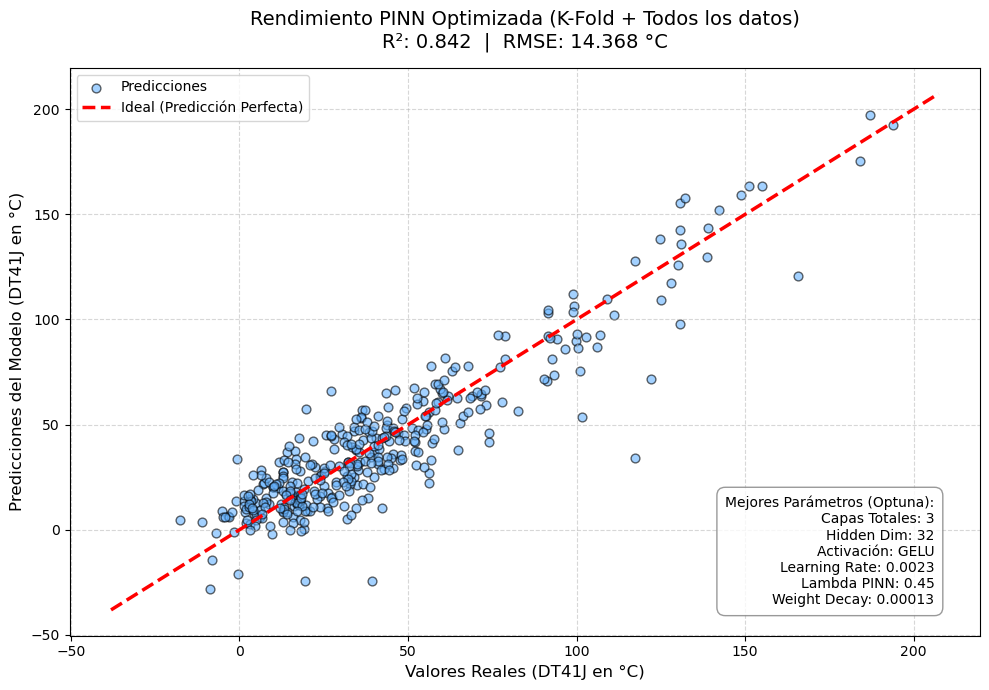

In [8]:
# --- GRÁFICA ---
fig, ax = plt.subplots(figsize=(10, 7))

# Dispersión
ax.scatter(y_true_unscaled, y_pred_unscaled, alpha=0.6, edgecolors='k', color='#66b3ff', s=40, label='Predicciones')

# Línea Ideal
min_val = min(y_true_unscaled.min(), y_pred_unscaled.min()) - 10
max_val = max(y_true_unscaled.max(), y_pred_unscaled.max()) + 10
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Ideal (Predicción Perfecta)')

ax.set_xlabel('Valores Reales (DT41J en °C)', fontsize=12)
ax.set_ylabel('Predicciones del Modelo (DT41J en °C)', fontsize=12)
ax.set_title(f'Rendimiento PINN Optimizada (K-Fold + Todos los datos)\nR²: {r2:.3f}  |  RMSE: {rmse:.3f} °C', fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=10)

textstr = '\n'.join((
    r'Mejores Parámetros (Optuna):',
    f'Capas Totales: {best_params["num_layers"]}',
    f'Hidden Dim: {best_params["hidden_dim"]}',
    f'Activación: {best_params["activation"]}',
    f'Learning Rate: {best_params["learning_rate"]:.4f}',
    f'Lambda PINN: {best_params["lambda_mono"]:.2f}',
    f'Weight Decay: {best_params["weight_decay"]:.5f}'
))

props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='gray', alpha=0.8)
ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()